# Credit Card Customer Churn Analysis
**Date:** 2026-04-12  
**Dataset:** [Bank Churners - Kaggle](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers)  
**Problem Statement:**  
A bank is experiencing customer churn in its credit card division. The goal is to analyze customer behavior and demographics to identify key drivers of churn, segment at-risk customers, and provide actionable recommendations to improve retention.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv(r'D:\ITI\python visualization\Day02\project\files\BankChurners.csv')
print('Dataset loaded successfully')
print('Shape:', df.shape)

Dataset loaded successfully
Shape: (10127, 23)


---
## Section 1 — Data Quality Checking

### 1.1 Schema Preview

In [4]:
print('Shape:', df.shape)
print()
df.head()

Shape: (10127, 23)



,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [6]:
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990


### 1.2 Missing Values

In [7]:
# Check NaN values
print('=== NaN Values ===')
print(df.isnull().sum())

print()
print('=== "Unknown" String Values ===')
for col in df.select_dtypes(include='object').columns:
    count = (df[col] == 'Unknown').sum()
    if count > 0:
        pct = round(count / len(df) * 100, 2)
        print(f'{col}: {count} ({pct}%)')

=== NaN Values ===
CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category              

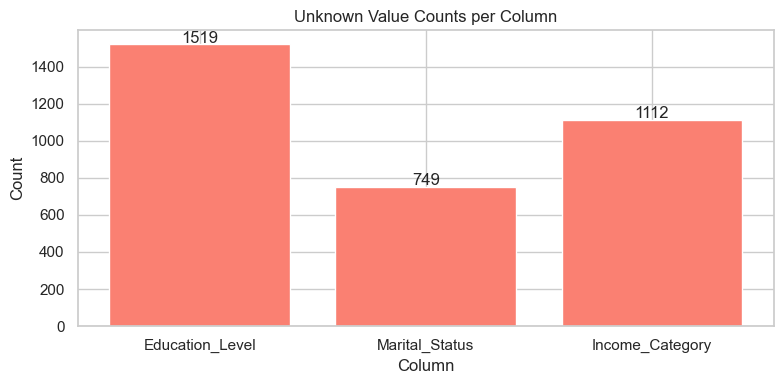

In [8]:
# Visualize Unknown distribution
unknown_counts = {}
for col in df.select_dtypes(include='object').columns:
    count = (df[col] == 'Unknown').sum()
    if count > 0:
        unknown_counts[col] = count

plt.figure(figsize=(8, 4))
plt.bar(unknown_counts.keys(), unknown_counts.values(), color='salmon')
plt.title('Unknown Value Counts per Column')
plt.ylabel('Count')
plt.xlabel('Column')
for i, (k, v) in enumerate(unknown_counts.items()):
    plt.text(i, v + 10, str(v), ha='center')
plt.tight_layout()
plt.show()

### 1.3 Duplicates

In [9]:
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate CLIENTNUM:', df['CLIENTNUM'].duplicated().sum())

Duplicate rows: 0
Duplicate CLIENTNUM: 0


### 1.4 Type Checks

In [10]:
print('Numeric columns:')
print(df.select_dtypes(include='number').columns.tolist())
print()
print('Categorical columns:')
print(df.select_dtypes(include='object').columns.tolist())

Numeric columns:
['CLIENTNUM', 'Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']

Categorical columns:
['Attrition_Flag', 'Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


### 1.5 Outliers

In [11]:
print('=== Outliers per Numeric Column (IQR Method) ===')
outlier_summary = {}
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c not in ['CLIENTNUM']]

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 3 * IQR) | (df[col] > Q3 + 3 * IQR)).sum()
    if outliers > 0:
        outlier_summary[col] = outliers
        print(f'{col}: {outliers}')

=== Outliers per Numeric Column (IQR Method) ===
Total_Amt_Chng_Q4_Q1: 90
Total_Trans_Amt: 737
Total_Ct_Chng_Q4_Q1: 80
Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1: 1631
Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2: 1631


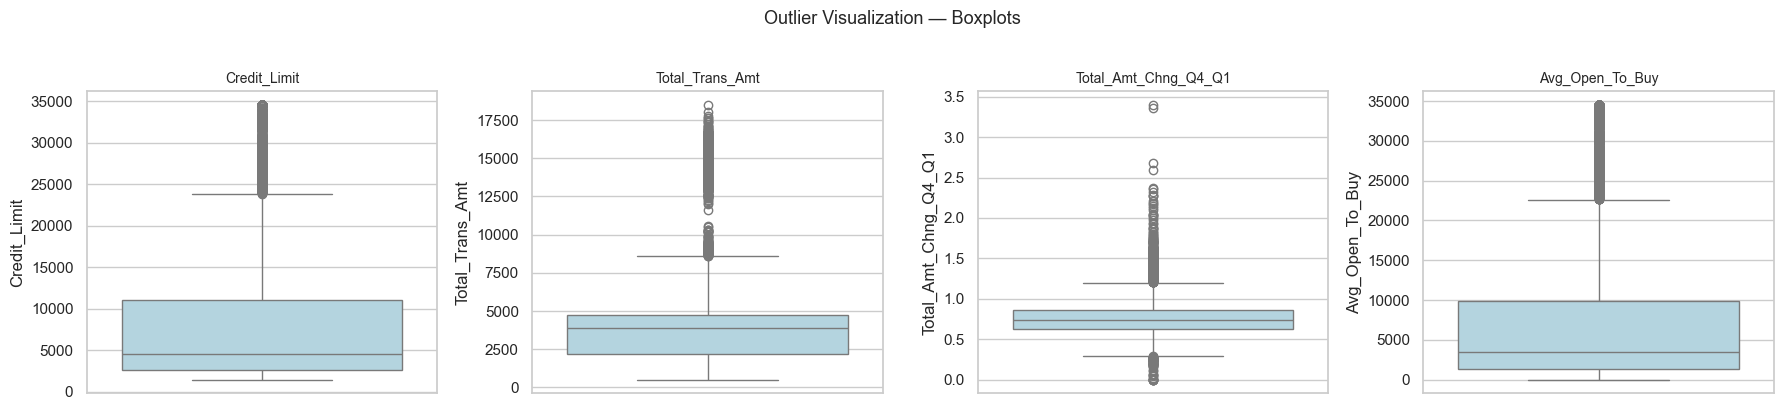

In [12]:
# Boxplots for key columns with outliers
key_cols = ['Credit_Limit', 'Total_Trans_Amt', 'Total_Amt_Chng_Q4_Q1', 'Avg_Open_To_Buy']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, key_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightblue')
    ax.set_title(col, fontsize=10)
plt.suptitle('Outlier Visualization — Boxplots', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 1.6 Sanity Checks

In [13]:
print('Age range:', df['Customer_Age'].min(), '-', df['Customer_Age'].max())
print('Utilization Ratio range:', df['Avg_Utilization_Ratio'].min(), '-', df['Avg_Utilization_Ratio'].max())
print('Dependent count range:', df['Dependent_count'].min(), '-', df['Dependent_count'].max())
print('Credit Limit > 0:', (df['Credit_Limit'] > 0).all())

# Avg_Open_To_Buy should equal Credit_Limit - Total_Revolving_Bal
df['_check'] = round(df['Credit_Limit'] - df['Total_Revolving_Bal'], 2)
mismatch = (df['_check'] != df['Avg_Open_To_Buy']).sum()
print(f'Avg_Open_To_Buy mismatch with Credit_Limit - Revolving_Bal: {mismatch}')
df.drop(columns=['_check'], inplace=True)

Age range: 26 - 73
Utilization Ratio range: 0.0 - 0.999
Dependent count range: 0 - 5
Credit Limit > 0: True
Avg_Open_To_Buy mismatch with Credit_Limit - Revolving_Bal: 0


### 1.7 Data Quality Summary

In [14]:
summary = pd.DataFrame({
    'Issue': ['NaN Values', 'Unknown - Education_Level', 'Unknown - Marital_Status',
              'Unknown - Income_Category', 'Duplicate Rows', 'Outliers (Credit_Limit)',
              'Outliers (Total_Trans_Amt)', 'Leakage Columns', 'ID Column'],
    'Count': [0, 1519, 749, 1112, 0, 984, 896, 2, 1],
    'Action': ['None needed', 'Keep as category', 'Keep as category',
               'Keep as category', 'None needed', 'Cap with IQR',
               'Cap with IQR', 'Drop', 'Drop']
})
summary

,Issue,Count,Action
0,NaN Values,0,None needed
1,Unknown - Education_Level,1519,Keep as category
2,Unknown - Marital_Status,749,Keep as category
3,Unknown - Income_Category,1112,Keep as category
4,Duplicate Rows,0,None needed
5,Outliers (Credit_Limit),984,Cap with IQR
6,Outliers (Total_Trans_Amt),896,Cap with IQR
7,Leakage Columns,2,Drop
8,ID Column,1,Drop


---
## Section 2 — Wrangling / Cleaning

### 2.1 Drop Useless Columns
**Justification:**  
- `CLIENTNUM`: random ID with no predictive value  
- Naive Bayes columns: pre-computed from the target variable — keeping them causes data leakage

In [15]:
df.drop(columns=[
    'CLIENTNUM',
    df.columns[-1],
    df.columns[-2]
], inplace=True)
print('Remaining columns:', df.shape[1])
print(df.columns.tolist())

Remaining columns: 20
['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


### 2.2 Type Casting — Encode Binary Columns

In [16]:
df['Attrition_Flag'] = df['Attrition_Flag'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1
})

df['Gender'] = df['Gender'].map({'M': 0, 'F': 1})

print('Attrition_Flag values:', df['Attrition_Flag'].unique())
print('Gender values:', df['Gender'].unique())

Attrition_Flag values: [0 1]
Gender values: [0 1]


### 2.3 Handling Unknown Values
**Justification:** Unknown values represent ~7–15% of data. Dropping rows would cause significant data loss. Customers who do not disclose income/education may have distinct churn behavior — keeping "Unknown" as a valid category preserves this signal.

In [17]:
# Keep Unknown as a category — no change needed
print('Unknown counts kept as category:')
for col in ['Education_Level', 'Marital_Status', 'Income_Category']:
    print(f'  {col}: {(df[col] == "Unknown").sum()}')

Unknown counts kept as category:
  Education_Level: 1519
  Marital_Status: 749
  Income_Category: 1112


### 2.4 Ordinal Encoding

In [18]:
education_order = [['Unknown', 'Uneducated', 'High School', 'College', 'Graduate', 'Post-Graduate', 'Doctorate']]
income_order    = [['Unknown', 'Less than $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +']]
card_order      = [['Blue', 'Silver', 'Gold', 'Platinum']]
marital_order   = [['Unknown', 'Single', 'Married', 'Divorced']]

df['Education_Level'] = OrdinalEncoder(categories=education_order).fit_transform(df[['Education_Level']])
df['Income_Category'] = OrdinalEncoder(categories=income_order).fit_transform(df[['Income_Category']])
df['Card_Category']   = OrdinalEncoder(categories=card_order).fit_transform(df[['Card_Category']])
df['Marital_Status']  = OrdinalEncoder(categories=marital_order).fit_transform(df[['Marital_Status']])

print('Encoding done')
df[['Education_Level', 'Income_Category', 'Card_Category', 'Marital_Status']].head()

Encoding done


,Education_Level,Income_Category,Card_Category,Marital_Status
0,2.0,3.0,0.0,2.0
1,4.0,1.0,0.0,1.0
2,4.0,4.0,0.0,2.0
3,2.0,1.0,0.0,0.0
4,1.0,3.0,0.0,2.0


### 2.5 Feature Engineering

In [19]:
# Age Group
df['Age_Group'] = pd.cut(df['Customer_Age'],
                          bins=[0, 35, 50, 100],
                          labels=['Young (<35)', 'Middle (35-50)', 'Senior (50+)'])

# Utilization Group
df['Utilization_Group'] = pd.cut(df['Avg_Utilization_Ratio'],
                                   bins=[-0.01, 0.1, 0.4, 1.0],
                                   labels=['Low', 'Medium', 'High'])

# Transaction Frequency per month
df['Transaction_Frequency'] = df['Total_Trans_Ct'] / df['Months_on_book']

print('New features added: Age_Group, Utilization_Group, Transaction_Frequency')
df[['Age_Group', 'Utilization_Group', 'Transaction_Frequency']].head()

New features added: Age_Group, Utilization_Group, Transaction_Frequency


,Age_Group,Utilization_Group,Transaction_Frequency
0,Middle (35-50),Low,1.076923
1,Middle (35-50),Medium,0.750000
2,Senior (50+),Low,0.555556
3,Middle (35-50),High,0.588235
4,Middle (35-50),Low,1.333333


### 2.6 De-noising — Cap Outliers with IQR Winsorization
**Justification:** Extreme outliers in financial data often reflect data entry errors or rare edge cases. Capping (not removing) preserves data size while reducing noise.

In [20]:
cap_cols = ['Credit_Limit', 'Avg_Open_To_Buy', 'Total_Trans_Amt',
            'Total_Amt_Chng_Q4_Q1', 'Total_Ct_Chng_Q4_Q1',
            'Contacts_Count_12_mon', 'Months_on_book']

for col in cap_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 3 * IQR, Q3 + 3 * IQR)

print('Outliers capped for:', cap_cols)

Outliers capped for: ['Credit_Limit', 'Avg_Open_To_Buy', 'Total_Trans_Amt', 'Total_Amt_Chng_Q4_Q1', 'Total_Ct_Chng_Q4_Q1', 'Contacts_Count_12_mon', 'Months_on_book']


In [21]:
print('Final cleaned shape:', df.shape)
df.head()

Final cleaned shape: (10127, 23)


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Age_Group,Utilization_Group,Transaction_Frequency
0,0,45,0,3,2.0,2.0,3.0,0.0,39,5,...,777,11914.0,1.335,1144.0,42,1.526,0.061,Middle (35-50),Low,1.076923
1,0,49,1,5,4.0,1.0,1.0,0.0,44,6,...,864,7392.0,1.541,1291.0,33,1.526,0.105,Middle (35-50),Medium,0.750000
2,0,51,0,3,4.0,2.0,4.0,0.0,36,4,...,0,3418.0,1.543,1887.0,20,1.526,0.000,Senior (50+),Low,0.555556
3,0,40,1,4,2.0,0.0,1.0,0.0,34,3,...,2517,796.0,1.405,1171.0,20,1.526,0.760,Middle (35-50),High,0.588235
4,0,40,0,3,1.0,2.0,3.0,0.0,21,5,...,0,4716.0,1.543,816.0,28,1.526,0.000,Middle (35-50),Low,1.333333


---
## Section 3 — EDA

### 3.1 Univariate Analysis — Target Variable

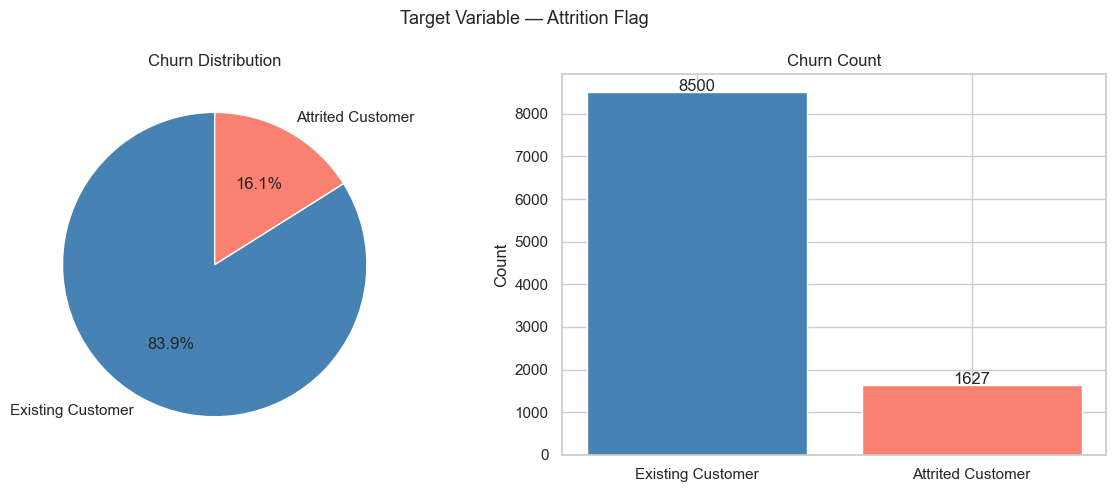

Overall Churn Rate: 16.07%


In [22]:
churn_counts = df['Attrition_Flag'].value_counts()
labels = ['Existing Customer', 'Attrited Customer']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(churn_counts, labels=labels, autopct='%1.1f%%',
            colors=['steelblue', 'salmon'], startangle=90)
axes[0].set_title('Churn Distribution')

axes[1].bar(labels, churn_counts.values, color=['steelblue', 'salmon'])
axes[1].set_title('Churn Count')
axes[1].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[1].text(i, v + 30, str(v), ha='center')

plt.suptitle('Target Variable — Attrition Flag', fontsize=13)
plt.tight_layout()
plt.show()

churn_rate = round(churn_counts[1] / len(df) * 100, 2)
print(f'Overall Churn Rate: {churn_rate}%')

### 3.2 Univariate Analysis — Numeric Distributions

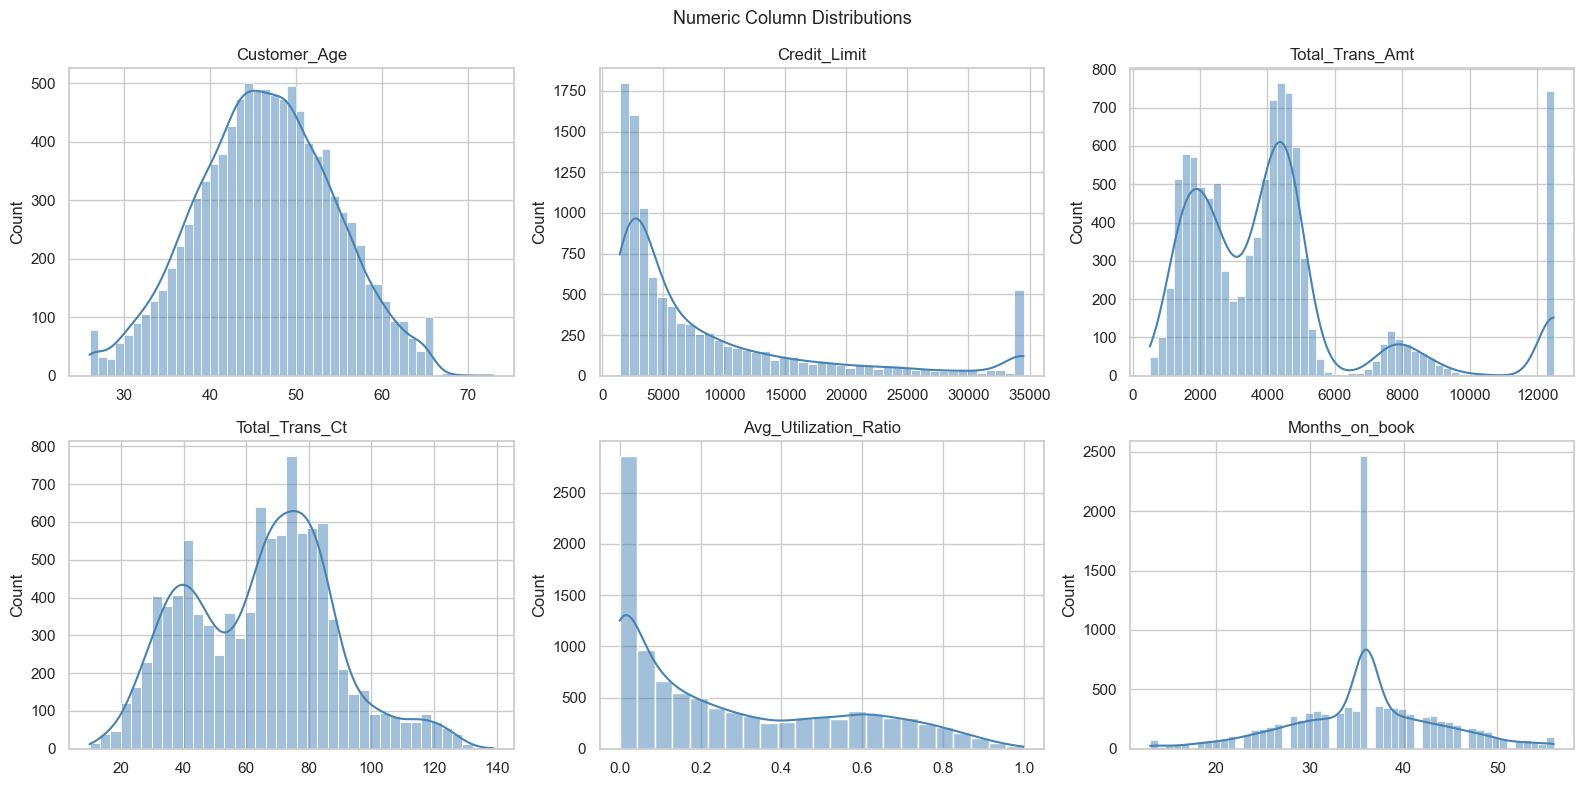

In [23]:
num_cols = ['Customer_Age', 'Credit_Limit', 'Total_Trans_Amt',
            'Total_Trans_Ct', 'Avg_Utilization_Ratio', 'Months_on_book']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('')

plt.suptitle('Numeric Column Distributions', fontsize=13)
plt.tight_layout()
plt.show()

### 3.3 Bivariate Analysis — Churn vs Numeric Features

C:\Users\MoazAshraf\AppData\Local\Temp\ipykernel_13884\1107716012.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition_Flag', y=col, data=df, ax=ax,
C:\Users\MoazAshraf\AppData\Local\Temp\ipykernel_13884\1107716012.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Existing', 'Attrited'])
C:\Users\MoazAshraf\AppData\Local\Temp\ipykernel_13884\1107716012.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition_Flag', y=col, data=df, ax=ax,
C:\Users\MoazAshraf\AppData\Local\Temp\ipykernel_13884\1107716012.py:8: UserWarning: set_ticklabels() should only be used with a 

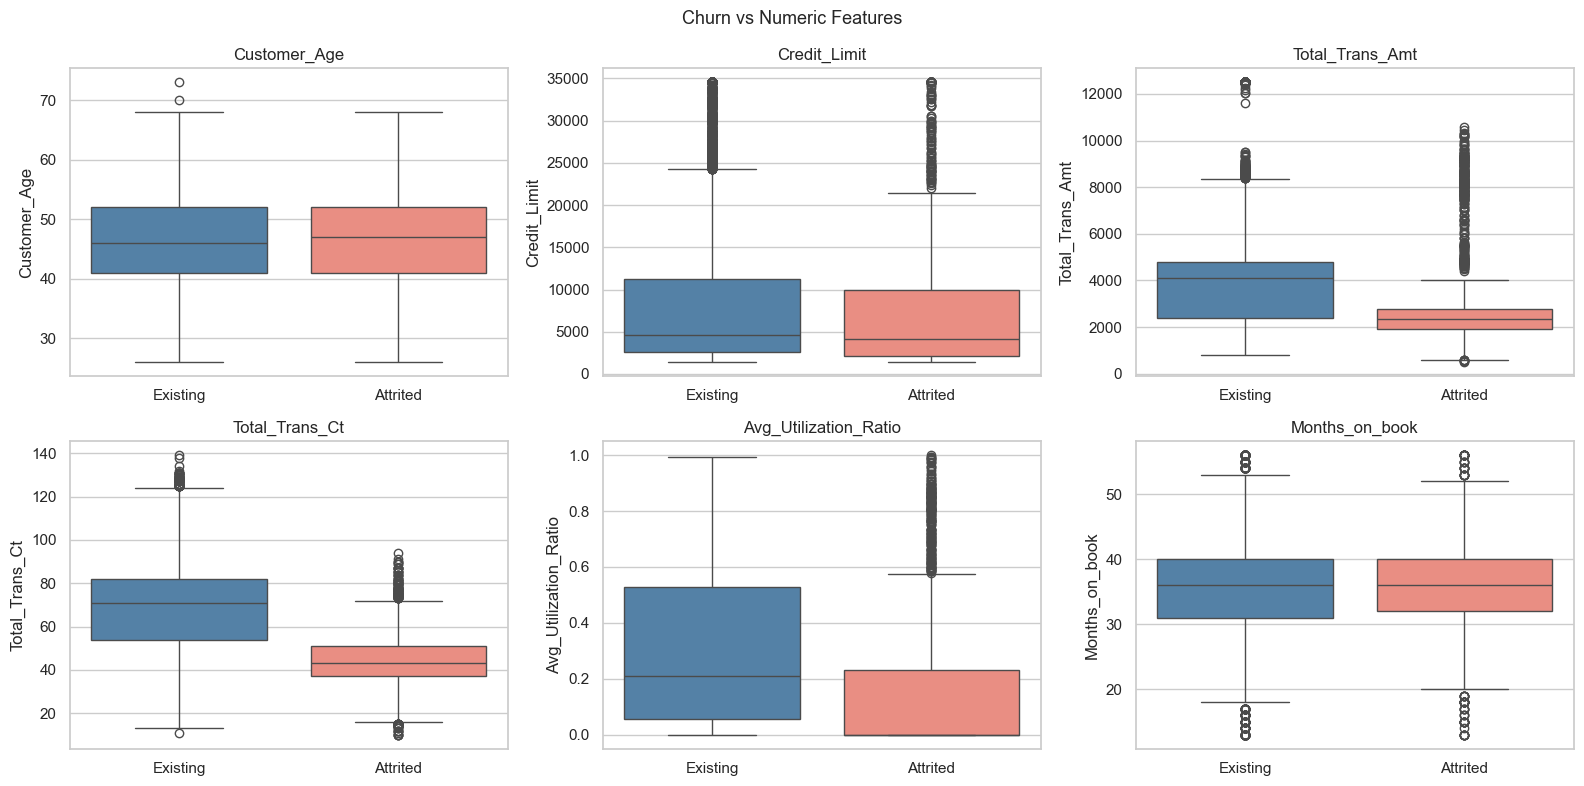

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(x='Attrition_Flag', y=col, data=df, ax=ax,
                palette={0: 'steelblue', 1: 'salmon', '0': 'steelblue', '1': 'salmon'}) # Updated palette
    ax.set_title(col)
    ax.set_xticklabels(['Existing', 'Attrited'])
    ax.set_xlabel('')

plt.suptitle('Churn vs Numeric Features', fontsize=13)
plt.tight_layout()
plt.show()


### 3.4 Segment Analysis — Churn Rate by Category

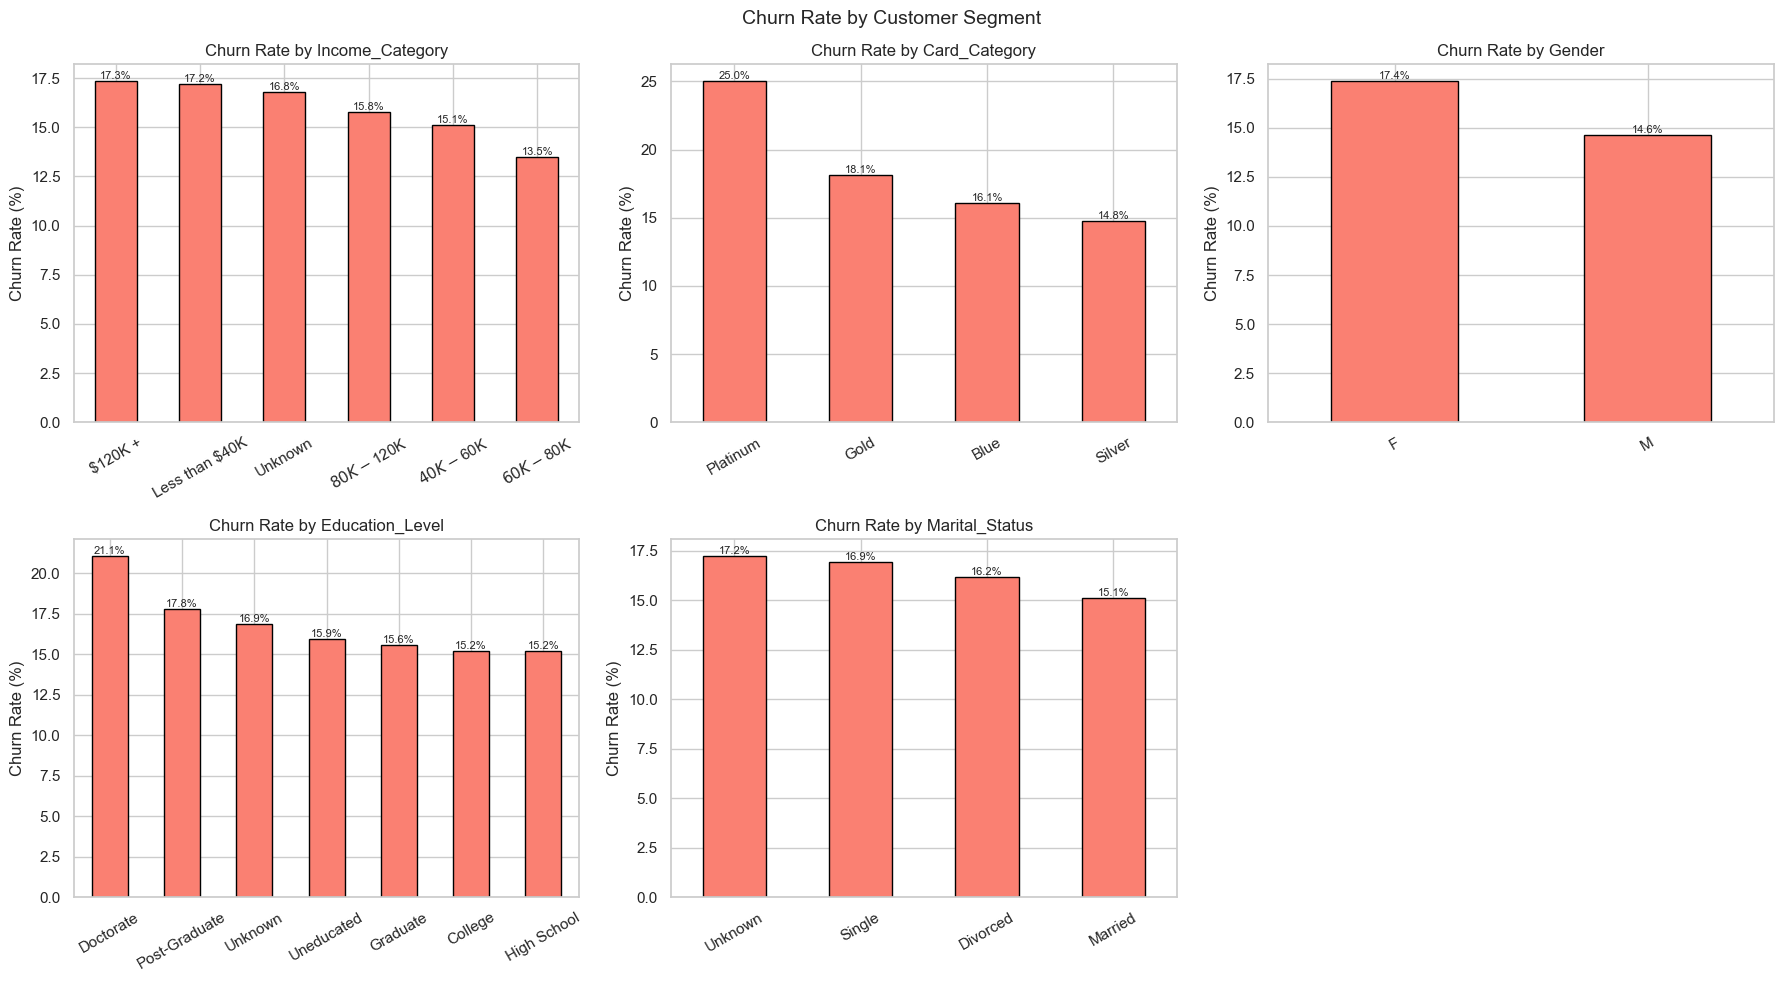

In [25]:
# Reload original labels for readability
df_orig = pd.read_csv(r'D:\ITI\python visualization\Day02\project\files\BankChurners.csv')
df_orig['Churned'] = (df_orig['Attrition_Flag'] == 'Attrited Customer').astype(int)

cat_cols = ['Income_Category', 'Card_Category', 'Gender', 'Education_Level', 'Marital_Status']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    churn_rate_col = df_orig.groupby(col)['Churned'].mean().sort_values(ascending=False) * 100
    churn_rate_col.plot(kind='bar', ax=ax, color='salmon', edgecolor='black')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Churn Rate by Customer Segment', fontsize=14)
plt.tight_layout()
plt.show()

### 3.5 Correlation Heatmap

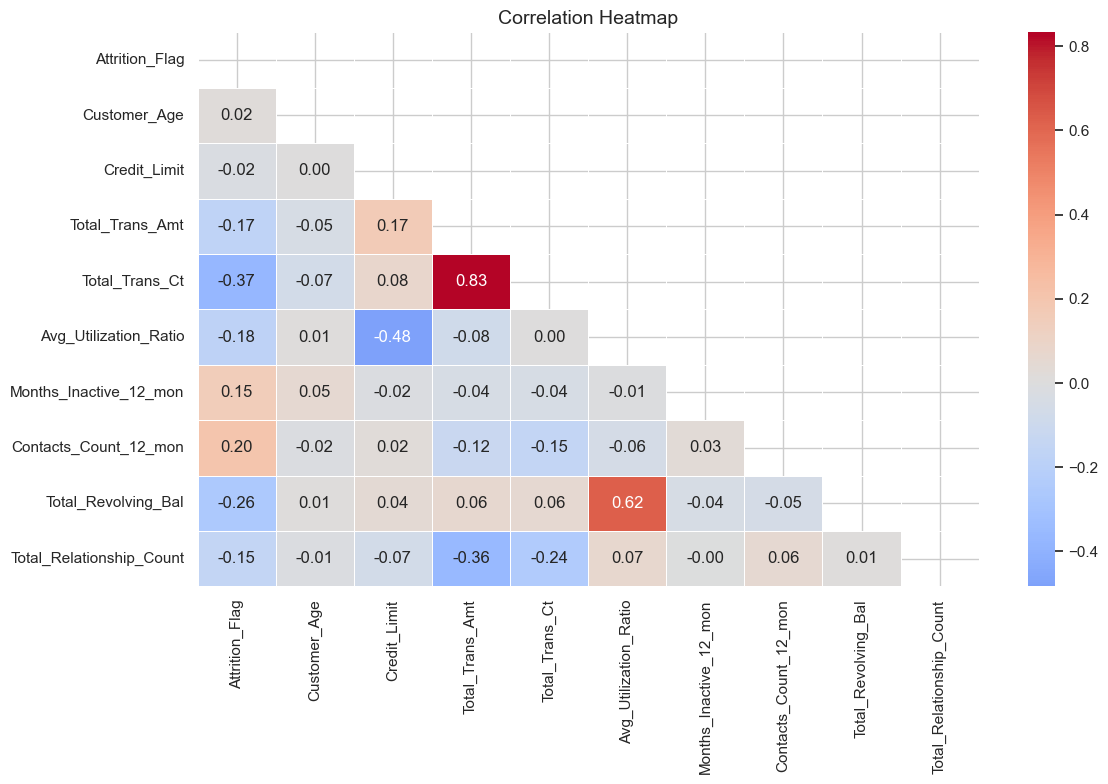

In [26]:
corr_cols = ['Attrition_Flag', 'Customer_Age', 'Credit_Limit', 'Total_Trans_Amt',
             'Total_Trans_Ct', 'Avg_Utilization_Ratio', 'Months_Inactive_12_mon',
             'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Relationship_Count']

plt.figure(figsize=(12, 8))
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

### 3.6 Transaction Behavior — Churned vs Existing

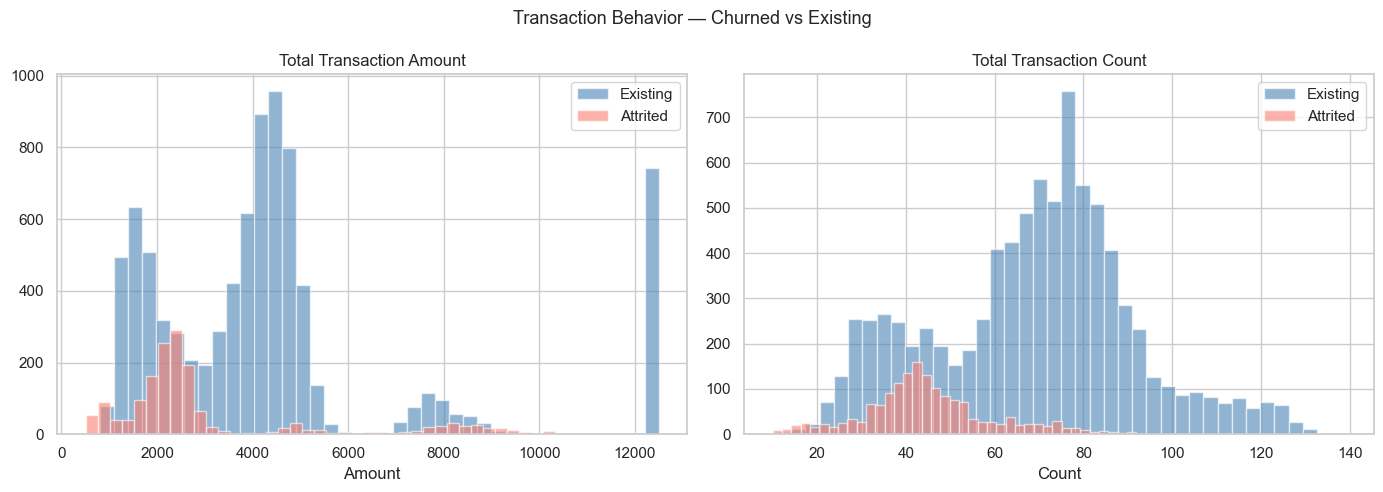

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for val, label, color in [(0, 'Existing', 'steelblue'), (1, 'Attrited', 'salmon')]:
    subset = df[df['Attrition_Flag'] == val]
    axes[0].hist(subset['Total_Trans_Amt'], bins=40, alpha=0.6, label=label, color=color)
    axes[1].hist(subset['Total_Trans_Ct'], bins=40, alpha=0.6, label=label, color=color)

axes[0].set_title('Total Transaction Amount')
axes[0].set_xlabel('Amount')
axes[0].legend()

axes[1].set_title('Total Transaction Count')
axes[1].set_xlabel('Count')
axes[1].legend()

plt.suptitle('Transaction Behavior — Churned vs Existing', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 4 — Business Questions

### Q1: What is the overall churn rate?

In [28]:
churn_rate = df['Attrition_Flag'].mean() * 100
print(f'Overall Churn Rate: {churn_rate:.2f}%')
print(f'Total Customers: {len(df)}')
print(f'Churned Customers: {df["Attrition_Flag"].sum()}')
print(f'Retained Customers: {(df["Attrition_Flag"] == 0).sum()}')

Overall Churn Rate: 16.07%
Total Customers: 10127
Churned Customers: 1627
Retained Customers: 8500


### Q2: Which income group churns the most?

                 count  churn_rate
Income_Category                   
$120K +            727       17.33
Less than $40K    3561       17.19
Unknown           1112       16.82
$80K - $120K      1535       15.77
$40K - $60K       1790       15.14
$60K - $80K       1402       13.48


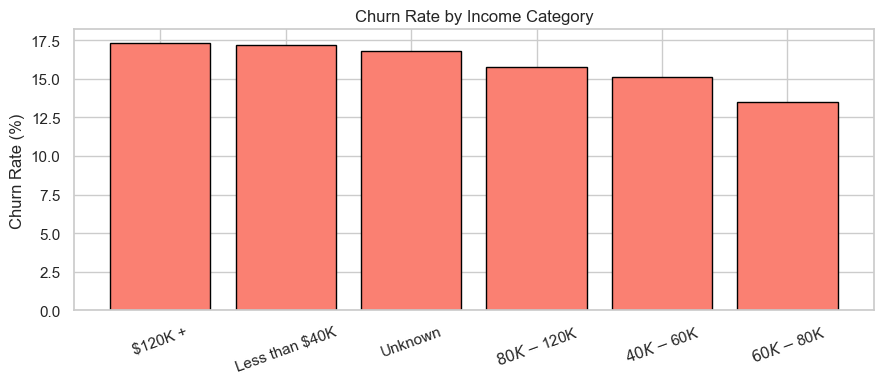

In [29]:
income_churn = df_orig.groupby('Income_Category')['Churned'].agg(['mean', 'count'])
income_churn['churn_rate'] = round(income_churn['mean'] * 100, 2)
income_churn = income_churn.sort_values('churn_rate', ascending=False)
print(income_churn[['count', 'churn_rate']])

plt.figure(figsize=(9, 4))
plt.bar(income_churn.index, income_churn['churn_rate'], color='salmon', edgecolor='black')
plt.title('Churn Rate by Income Category')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Q3: Do inactive customers churn more?

Months_Inactive_12_mon
0    51.724138
1     4.478280
2    15.386959
3    21.476859
4    29.885057
5    17.977528
6    15.322581
Name: Attrition_Flag, dtype: float64


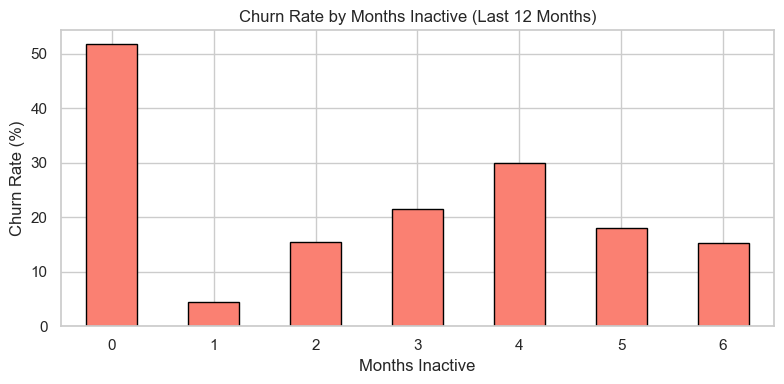

In [30]:
inactive_churn = df.groupby('Months_Inactive_12_mon')['Attrition_Flag'].mean() * 100
print(inactive_churn)

plt.figure(figsize=(8, 4))
inactive_churn.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Churn Rate by Months Inactive (Last 12 Months)')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Months Inactive')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Q4: Does credit limit affect churn?

Average Credit Limit:
Attrition_Flag
Existing    8726.877518
Attrited    8136.039459
Name: Credit_Limit, dtype: float64


C:\Users\MoazAshraf\AppData\Local\Temp\ipykernel_13884\1329064688.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition_Flag', y='Credit_Limit', data=df,


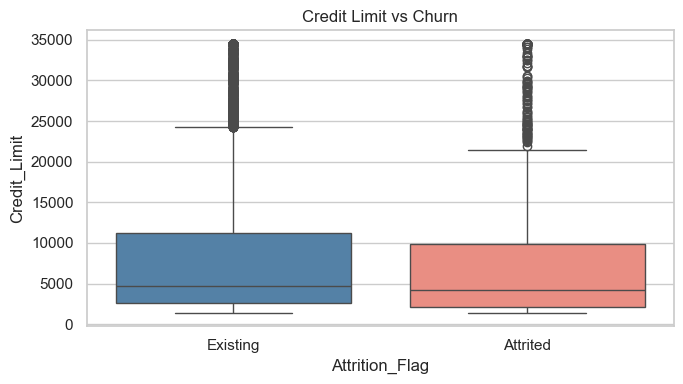

In [31]:
print('Average Credit Limit:')
print(df.groupby('Attrition_Flag')['Credit_Limit'].mean().rename({0: 'Existing', 1: 'Attrited'}))

plt.figure(figsize=(7, 4))
sns.boxplot(x='Attrition_Flag', y='Credit_Limit', data=df,
palette={'0': 'steelblue', '1': 'salmon', 0: 'steelblue', 1: 'salmon'})
plt.xticks([0, 1], ['Existing', 'Attrited'])
plt.title('Credit Limit vs Churn')
plt.tight_layout()
plt.show()

### Q5: Which card category has the highest churn rate?

               count  churn_rate
Card_Category                   
Platinum          20       25.00
Gold             116       18.10
Blue            9436       16.10
Silver           555       14.77


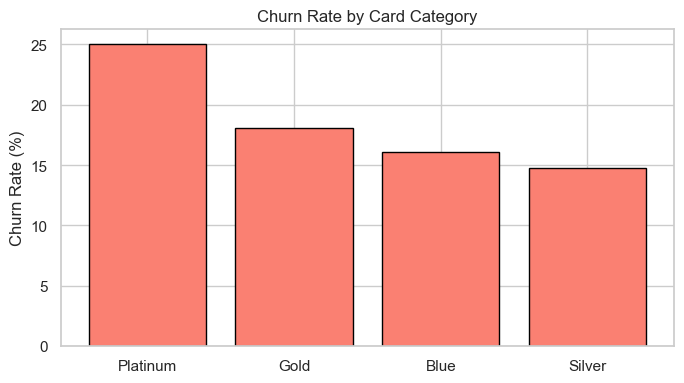

In [32]:
card_churn = df_orig.groupby('Card_Category')['Churned'].agg(['mean', 'count'])
card_churn['churn_rate'] = round(card_churn['mean'] * 100, 2)
card_churn = card_churn.sort_values('churn_rate', ascending=False)
print(card_churn[['count', 'churn_rate']])

plt.figure(figsize=(7, 4))
plt.bar(card_churn.index, card_churn['churn_rate'], color='salmon', edgecolor='black')
plt.title('Churn Rate by Card Category')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

### Q6: Do customers with more products churn less?

Total_Relationship_Count
1    25.604396
2    27.835881
3    17.353579
4    11.767782
5    12.004231
6    10.503751
Name: Attrition_Flag, dtype: float64


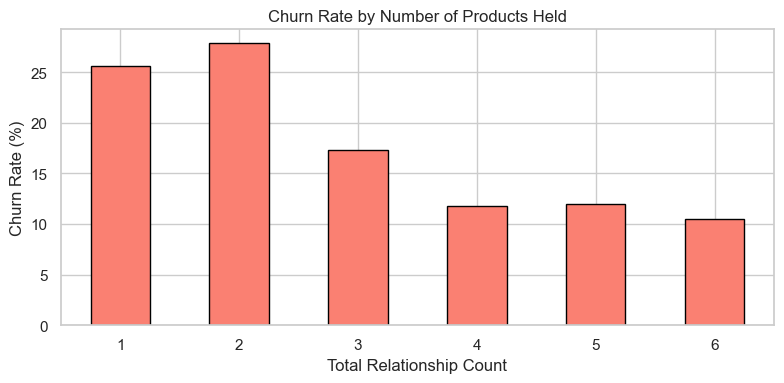

In [33]:
relationship_churn = df.groupby('Total_Relationship_Count')['Attrition_Flag'].mean() * 100
print(relationship_churn)

plt.figure(figsize=(8, 4))
relationship_churn.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Churn Rate by Number of Products Held')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Total Relationship Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Q7: What transaction behavior predicts churn?

Average Transaction Metrics by Churn Status:
          Total_Trans_Amt  Total_Trans_Ct  Transaction_Frequency
Existing      4460.934294       68.672588               2.037721
Attrited      3095.025814       44.933620               1.324407


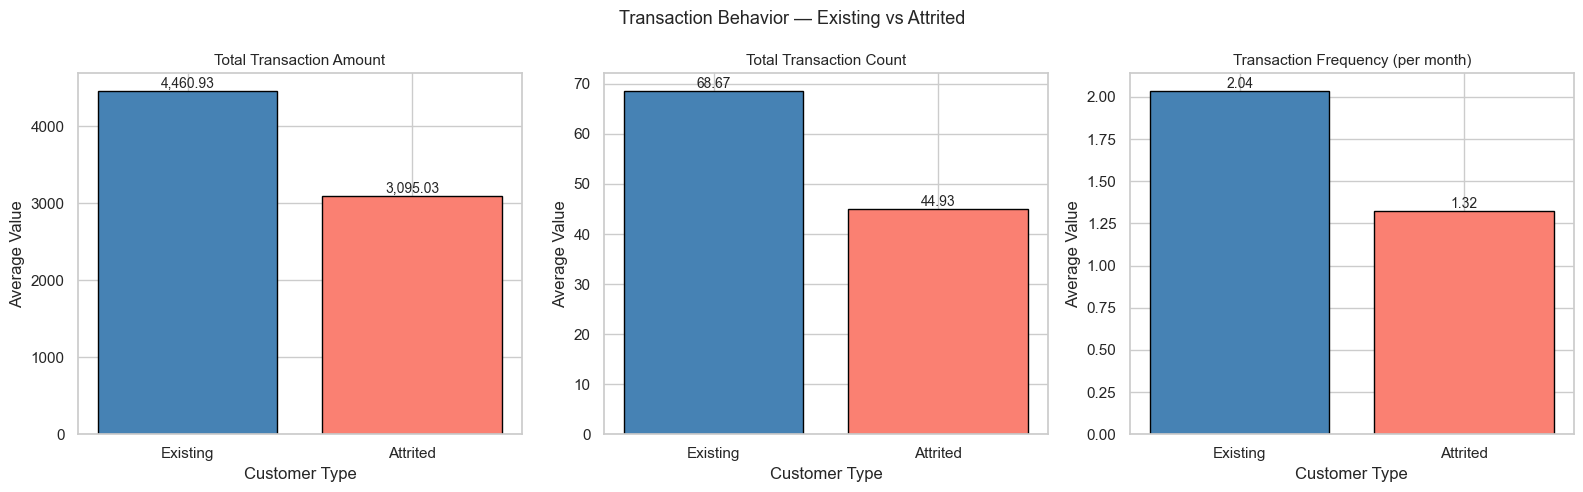

In [34]:
  print('Average Transaction Metrics by Churn Status:')
  result = df.groupby('Attrition_Flag')[['Total_Trans_Amt', 'Total_Trans_Ct', 'Transaction_Frequency']].mean()
  result.index = ['Existing', 'Attrited']
  print(result)

  metrics = ['Total_Trans_Amt', 'Total_Trans_Ct', 'Transaction_Frequency']
  titles  = ['Total Transaction Amount', 'Total Transaction Count', 'Transaction Frequency (per month)']

  fig, axes = plt.subplots(1, 3, figsize=(16, 5))

  for ax, metric, title in zip(axes, metrics, titles):
      values = result[metric]
      bars = ax.bar(values.index, values.values, color=['steelblue', 'salmon'], edgecolor='black')
      ax.set_title(title, fontsize=11)
      ax.set_ylabel('Average Value')
      ax.set_xlabel('Customer Type')
      for bar in bars:
          height = bar.get_height()
          ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:,.2f}', ha='center', va='bottom', fontsize=10)

  plt.suptitle('Transaction Behavior — Existing vs Attrited', fontsize=13)
  plt.tight_layout()
  plt.show()

---
## Section 5 — Insights & Recommendations

### Key Insights

1. **Churn rate is ~16%** — roughly 1 in 6 customers leaves. This is significant for a credit card portfolio.

2. **Low transaction activity is the strongest churn signal** — Attrited customers make far fewer transactions and spend less. This suggests disengagement before leaving.

3. **Inactivity drives churn** — Customers inactive for 3+ months in the past year have significantly higher churn rates.

4. **Fewer products = higher churn** — Customers with only 1–2 products churn at much higher rates than those with 4–6 products.

5. **Lower income customers churn more** — "Less than $40K" group shows the highest churn rate, possibly due to financial pressure.

6. **Blue card holders have the highest absolute churn** — They represent 93% of customers, so even a small % is a large number.

7. **Credit limit is lower for churned customers** — Attrited customers had lower credit limits on average, suggesting they may feel underserved.

---

### Recommendations

| # | Recommendation | Target Segment | Evidence |
|---|---|---|---|
| 1 | **Set up early-warning alerts** for customers with declining transaction count over 2+ months | All customers | Q7 — transaction drop precedes churn |
| 2 | **Re-engage inactive customers** with personalized offers after 2 months of inactivity | Months_Inactive ≥ 2 | Q3 — inactivity correlates with churn |
| 3 | **Cross-sell additional products** to single-product customers | Total_Relationship_Count = 1–2 | Q6 — more products = lower churn |
| 4 | **Offer credit limit increases** to loyal low-limit customers | Credit_Limit < median | Q4 — low limit linked to churn |
| 5 | **Design loyalty programs for low-income customers** | Income < $40K | Q2 — highest churn rate segment |
| 6 | **Upgrade Blue cardholders** showing strong engagement to Silver/Gold | Blue card power users | Q5 + card distribution |